# Experiment Analysis

Analysis of screening-focused hyperparameter tuning results from `results.tsv`, with `bin_acc` as the main metric and `mc_acc` as supporting context.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV with the current experiment schema.
df = pd.read_csv("results.tsv", sep="\t")
for col in ["mc_acc", "bin_acc", "memory_gb"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["status"] = df["status"].astype(str).str.strip().str.upper()
df["is_kept"] = df["status"] == "KEEP"
df["exp_idx"] = np.arange(len(df))

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Kept experiments: {df['is_kept'].sum()}")
df.head(10)

Total experiments: 70
Columns: ['commit', 'mc_acc', 'bin_acc', 'memory_gb', 'status', 'description', 'is_kept', 'exp_idx']
Kept experiments: 5


,commit,mc_acc,bin_acc,memory_gb,status,description,is_kept,exp_idx
0,228791f,0.286017,0.811441,0.3,KEEP,e01_baseline_sgd,True,0
1,228791f,0.567797,0.896186,0.5,KEEP,e02_wide_sgd (best bin_acc),True,1
2,228791f,0.432203,0.735169,0.4,DISCARD,e03_deep_sgd,False,2
3,228791f,0.580508,0.822034,0.2,DISCARD,e04_lite_sgd (best mc_acc),False,3
4,228791f,0.555085,0.879237,0.3,DISCARD,e05_baseline_adamw,False,4
5,228791f,0.122881,0.849576,0.7,DISCARD,e06_deep_bs8 (collapsed mc_acc; bs8+lr0.012 un...,False,5
6,228791f,0.279661,0.548729,0.5,DISCARD,e07_wide_adamw,False,6
7,228791f,0.527542,0.743644,0.5,DISCARD,e08_wide_sgd_lr005 (worse than e02 on mc+bin),False,7
8,228791f,0.508475,0.720339,0.8,DISCARD,e09_wide_sgd_bs8 (worse mc+bin vs e02 bs4),False,8
9,228791f,0.468220,0.828390,1.5,DISCARD,e10_wide_sgd_bs16 (worse mc+bin vs e02 bs4; ~1...,False,9


In [25]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

best_bin_row = df.loc[df["bin_acc"].idxmax()]
best_mc_row = df.loc[df["mc_acc"].idxmax()]
print(f"\nBest bin_acc: {best_bin_row['bin_acc']:.6f}  ({best_bin_row['description']})")
print(f"Best mc_acc:  {best_mc_row['mc_acc']:.6f}  ({best_mc_row['description']})")
print(f"Current screening winner status: {best_bin_row['status']}")

Experiment outcomes:
status
DISCARD    65
KEEP        5

Keep rate: 5/70 = 7.1%

Best bin_acc: 0.951271  (e34_mnv3_difflr_bb1p5e4_hd01_pos125 (new best bin_acc; lower backbone LR helps screening))
Best mc_acc:  0.703390  (e53_mnv3_bb1p5e4_hd01_pos125_seed7 (repeatability check shows best bin_acc is not stable across seeds))
Current screening winner status: KEEP


In [26]:
# Show all kept experiments with bin_acc first and mc_acc as side context.
kept = df[df["is_kept"]].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    desc = row["description"]
    print(
        f"  #{i:3d}  bin={row['bin_acc']:.6f}  mc={row['mc_acc']:.6f}  "
        f"mem={row['memory_gb']:.1f}GB  {desc}"
    )

KEPT experiments (5 total):

  #  0  bin=0.811441  mc=0.286017  mem=0.3GB  e01_baseline_sgd
  #  1  bin=0.896186  mc=0.567797  mem=0.5GB  e02_wide_sgd (best bin_acc)
  # 10  bin=0.923729  mc=0.567797  mem=0.5GB  e11_wide_lr012
  # 29  bin=0.936441  mc=0.675847  mem=0.5GB  e30_mnv3_difflr_bb2e4_hd01_pos125 (new best bin_acc and mc_acc with mild positive-class boost)
  # 33  bin=0.951271  mc=0.635593  mem=0.5GB  e34_mnv3_difflr_bb1p5e4_hd01_pos125 (new best bin_acc; lower backbone LR helps screening)


## Bin Acc Progress

Track how the best kept `bin_acc` evolves as experiments progress. The running maximum shows the current screening frontier, while `mc_acc` appears in a side panel for supporting context.

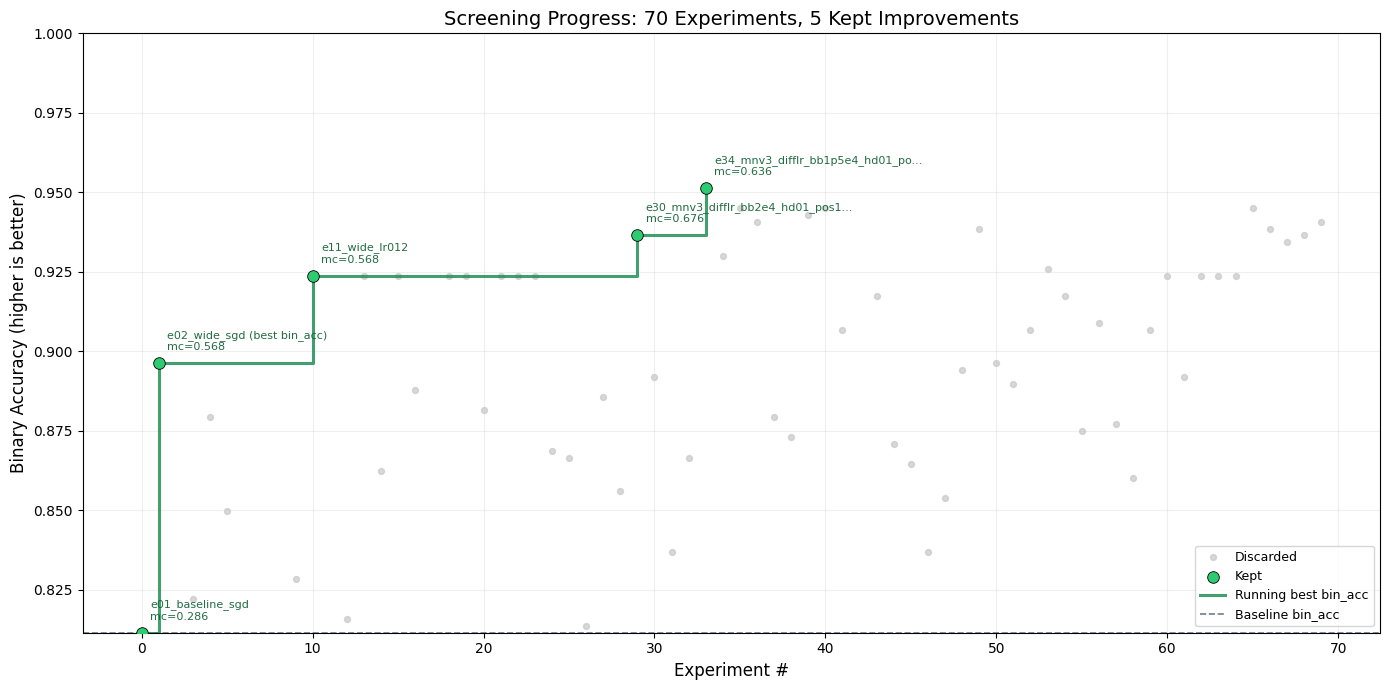

Saved to progress.png


In [27]:
fig, ax = plt.subplots(figsize=(14, 7))

valid = df[df["status"] != "CRASH"].copy().reset_index(drop=True)
baseline_bin = valid.loc[0, "bin_acc"]

# Main view: bin_acc over time, with kept runs emphasized.
disc = valid[valid["status"] == "DISCARD"]
ax.scatter(
    disc.index,
    disc["bin_acc"],
    c="#c7c7c7",
    s=18,
    alpha=0.7,
    zorder=2,
    label="Discarded",
)

kept_v = valid[valid["status"] == "KEEP"]
ax.scatter(
    kept_v.index,
    kept_v["bin_acc"],
    c="#2ecc71",
    s=70,
    zorder=4,
    label="Kept",
    edgecolors="black",
    linewidths=0.6,
)

running_best = kept_v["bin_acc"].cummax()
ax.step(
    kept_v.index,
    running_best,
    where="post",
    color="#1f8f55",
    linewidth=2.2,
    alpha=0.85,
    zorder=3,
    label="Running best bin_acc",
)

for idx, row in kept_v.iterrows():
    desc = str(row["description"]).strip()
    if len(desc) > 34:
        desc = desc[:31] + "..."
    label = f"{desc}\nmc={row['mc_acc']:.3f}"
    ax.annotate(
        label,
        (idx, row["bin_acc"]),
        textcoords="offset points",
        xytext=(6, 8),
        fontsize=8,
        color="#166437",
        alpha=0.95,
        ha="left",
        va="bottom",
    )

n_total = len(df)
n_kept = int(df["is_kept"].sum())
ax.axhline(baseline_bin, color="#34495e", linestyle="--", linewidth=1.2, alpha=0.7, label="Baseline bin_acc")
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Binary Accuracy (higher is better)", fontsize=12)
ax.set_title(f"Screening Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.2)
ax.set_ylim(baseline_bin, 1.0)


plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")


## Summary Statistics

In [28]:
# Summary stats
kept = df[df["is_kept"]].copy()
baseline_row = df.iloc[0]
best_bin_row = kept.loc[kept["bin_acc"].idxmax()]
best_mc_row = df.loc[df["mc_acc"].idxmax()]

print(f"Baseline bin_acc:  {baseline_row['bin_acc']:.6f}")
print(f"Baseline mc_acc:   {baseline_row['mc_acc']:.6f}")
print(f"Best kept bin_acc: {best_bin_row['bin_acc']:.6f}")
print(f"Best kept mc_acc:  {best_bin_row['mc_acc']:.6f}")
print(
    f"Bin_acc improvement: {best_bin_row['bin_acc'] - baseline_row['bin_acc']:+.6f} "
    f"({(best_bin_row['bin_acc'] - baseline_row['bin_acc']) / baseline_row['bin_acc'] * 100:.2f}%)"
)
print(f"Screening winner:   {best_bin_row['description']}")
print()
print(f"Side best mc_acc:   {best_mc_row['mc_acc']:.6f} ({best_mc_row['status']})")
print(f"Side best mc run:   {best_mc_row['description']}")
print(f"Its bin_acc:        {best_mc_row['bin_acc']:.6f}")
print()

print("Cumulative screening frontier:")
kept_sorted = kept.reset_index()
for _, row in kept_sorted.iterrows():
    desc = str(row["description"]).strip()
    print(
        f"  Experiment #{row['index']:3d}: bin={row['bin_acc']:.6f}  "
        f"mc={row['mc_acc']:.6f}  {desc}"
    )

Baseline bin_acc:  0.811441
Baseline mc_acc:   0.286017
Best kept bin_acc: 0.951271
Best kept mc_acc:  0.635593
Bin_acc improvement: +0.139830 (17.23%)
Screening winner:   e34_mnv3_difflr_bb1p5e4_hd01_pos125 (new best bin_acc; lower backbone LR helps screening)

Side best mc_acc:   0.703390 (DISCARD)
Side best mc run:   e53_mnv3_bb1p5e4_hd01_pos125_seed7 (repeatability check shows best bin_acc is not stable across seeds)
Its bin_acc:        0.906780

Cumulative screening frontier:
  Experiment #  0: bin=0.811441  mc=0.286017  e01_baseline_sgd
  Experiment #  1: bin=0.896186  mc=0.567797  e02_wide_sgd (best bin_acc)
  Experiment # 10: bin=0.923729  mc=0.567797  e11_wide_lr012
  Experiment # 29: bin=0.936441  mc=0.675847  e30_mnv3_difflr_bb2e4_hd01_pos125 (new best bin_acc and mc_acc with mild positive-class boost)
  Experiment # 33: bin=0.951271  mc=0.635593  e34_mnv3_difflr_bb1p5e4_hd01_pos125 (new best bin_acc; lower backbone LR helps screening)


## Top Screening Gains (Kept Experiments by `bin_acc` Improvement)

In [29]:
# Each kept experiment's gain is measured vs the previous kept frontier.
kept = df[df["is_kept"]].copy()
kept["prev_bin_acc"] = kept["bin_acc"].shift(1)
kept["delta_bin_acc"] = kept["bin_acc"] - kept["prev_bin_acc"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by screening lift (biggest first)
hits = hits.sort_values("delta_bin_acc", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'Bin':>10}  {'MC':>10}  Description")
print("-" * 100)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(
        f"{rank:4d}  {row['delta_bin_acc']:+.6f}  {row['bin_acc']:.6f}  "
        f"{row['mc_acc']:.6f}  {row['description']}"
    )

print(f"\n{'':>4}  {hits['delta_bin_acc'].sum():+.6f}  {'':>10}  {'':>10}  TOTAL bin_acc lift over baseline")

Rank     Delta         Bin          MC  Description
----------------------------------------------------------------------------------------------------
   1  +0.084745  0.896186  0.567797  e02_wide_sgd (best bin_acc)
   2  +0.027543  0.923729  0.567797  e11_wide_lr012
   3  +0.014830  0.951271  0.635593  e34_mnv3_difflr_bb1p5e4_hd01_pos125 (new best bin_acc; lower backbone LR helps screening)
   4  +0.012712  0.936441  0.675847  e30_mnv3_difflr_bb2e4_hd01_pos125 (new best bin_acc and mc_acc with mild positive-class boost)

      +0.139830                          TOTAL bin_acc lift over baseline


In [30]:
# Side context: highest mc_acc runs, with bin_acc and keep/discard outcome.
top_mc = df.sort_values(["mc_acc", "bin_acc"], ascending=False).head(10).copy()

print(f"{'Rank':>4}  {'MC':>8}  {'Bin':>8}  {'Status':>8}  Description")
print("-" * 100)
for rank, (_, row) in enumerate(top_mc.iterrows(), 1):
    print(
        f"{rank:4d}  {row['mc_acc']:.6f}  {row['bin_acc']:.6f}  "
        f"{row['status']:>8}  {row['description']}"
    )

Rank        MC       Bin    Status  Description
----------------------------------------------------------------------------------------------------
   1  0.703390  0.917373   DISCARD  e55_mnv3_bb1p5e4_hd01_pos125_novflip_rot7p5_jitlow (conservative clinical augmentation improved mc_acc but not screening)
   2  0.703390  0.906780   DISCARD  e53_mnv3_bb1p5e4_hd01_pos125_seed7 (repeatability check shows best bin_acc is not stable across seeds)
   3  0.701271  0.944915   DISCARD  e41_mnv3_bb1p5e4_hd01_pos125_novflip (no vertical flip improved mc_acc, but bin_acc still below e34)
   4  0.697034  0.877119   DISCARD  e58_mnv3_bb1p5e4_hd01_pos130_novflip_oofcal (stronger positive weighting hurt both legacy and calibrated screening vs e57)
   5  0.692797  0.942797   DISCARD  e40_mnv3_bb1p5e4_hd01_pos125_evalhflip (TTA lifted mc_acc, but bin_acc stayed below e34)
   6  0.692797  0.917373   DISCARD  e44_mnv3_bb1p5e4_hd01_pos125_schednone (no scheduler regressed bin_acc vs plateau)
   7  0.686441